#Data-Driven Airbnb Market Intelligence & Revenue Optimization


#Project Objectives
Perform a comprehensive exploratory data analysis (EDA) to understand the structure, distribution, quality, and characteristics of the Airbnb listings dataset, while identifying patterns, anomalies, and relationships among variables.

Assess and improve data quality by identifying and handling missing values, duplicate records, inconsistent formats, outliers, and data type issues to ensure the dataset is accurate, reliable, and suitable for analysis.

Analyze the factors influencing Airbnb listing prices by examining how attributes such as room type, property type, location, host characteristics, accommodation capacity, amenities, and availability contribute to pricing variations.

Evaluate host performance and customer engagement by investigating relationships between host status (e.g., Superhost), review scores, number of reviews, response rates, and booking availability to understand factors associated with successful listings.

Conduct statistical analysis using descriptive statistics, measures of dispersion (variance and standard deviation), and distribution analysis to quantify variability, detect outliers, and support data-driven interpretations.

Develop meaningful features through feature engineering by transforming and creating new variables that enhance analytical depth, improve interpretability, and uncover hidden patterns within the dataset.

Create insightful visualizations through univariate, bivariate, and multivariate analyses to effectively communicate trends, correlations, customer behavior, and business patterns using professional data visualization techniques.

Generate actionable business insights and strategic recommendations that help hosts, property managers, and stakeholders optimize pricing strategies, improve customer satisfaction, increase occupancy rates, and support informed decision-making based on evidence from the analysis.

# Dataset Information

Source: Airbnb Listings Dataset

Number of observations: 92,638

Number of features: 90

Dataset Type:
Structured tabular dataset

Target of Analysis:
Understand Airbnb pricing, availability, host characteristics, customer reviews, and listing distribution.

#Initial Inspection / Initial EDA

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

pd.set_option("display.max_columns", None)

In [ ]:
import pandas as pd

# Direct link to the Airbnb dataset hosted on GitHub Releases
# Using Releases instead of a normal repo file because the file (210MB)
# exceeds GitHub's 25MB web-upload limit and 100MB git push limit.
url = "https://github.com/Gladiya-15-Analyst/London-Airbnb-Market-Analysis/releases/download/v1.0/Airbnb.Raw.dataset.csv"

# pandas can read directly from a URL — no need to manually download first
df = pd.read_csv(url)

# --- Sanity checks after loading ---
print("Shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values per column:")
print(df.isnull().sum())

Shape (rows, columns): (92638, 90)

Column names:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote

In [ ]:
df.shape

(92638, 90)

In [ ]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
       'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_c

In [ ]:
df.dtypes

,0
id,float64
listing_url,object
scrape_id,float64
last_scraped,object
source,object
...,...
calculated_host_listings_count,int64
calculated_host_listings_count_entire_homes,int64
calculated_host_listings_count_private_rooms,int64
calculated_host_listings_count_shared_rooms,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92638 entries, 0 to 92637
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            92638 non-null  float64
 1   listing_url                                   92638 non-null  object 
 2   scrape_id                                     92638 non-null  float64
 3   last_scraped                                  92638 non-null  object 
 4   source                                        92638 non-null  object 
 5   name                                          92638 non-null  object 
 6   description                                   90549 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   92633 non-null  object 
 9   host_id                                       92638 non-null 

In [ ]:
df.describe()

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_response_time,host_response_rate,host_acceptance_rate,host_thumbnail_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,neighbourhood,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price_quote_total_price,price_quote_price_per_night,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,9.263800e+04,9.263800e+04,0.0,9.263800e+04,9.256200e+04,0.0,92562.000000,92562.000000,92561.000000,92561.000000,0.0,0.0,0.0,0.0,0.0,92562.000000,0.0,0.0,0.0,0.0,92638.000000,92638.000000,92638.000000,57762.000000,68655.000000,60163.000000,62240.000000,62240.000000,92633.000000,9.263300e+04,92633.000000,92633.000000,9.263300e+04,9.263300e+04,92638.000000,9.263800e+04,0.0,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,6.224000e+04,70711.000000,70697.000000,70702.000000,70673.000000,70692.000000,70672.000000,70672.000000,0.0,0.0,92638.000000,92638.000000,92638.000000,92638.000000,70711.000000
mean,8.174866e+17,2.026060e+13,NaN,1.361402e+16,1.475942e+18,NaN,7.670037,5.454539,5.556023,5.400352,NaN,NaN,NaN,NaN,NaN,53.821774,NaN,NaN,NaN,NaN,51.509225,-0.128647,3.387141,1.370174,1.767912,2.020993,1046.141884,271.469220,4.557631,2.148486e+05,4.557631,7.766563,7.572937e+04,2.148486e+05,6.017677,2.144453e+05,NaN,8.636737,21.756633,36.255165,152.664447,24.148654,6.113971,0.545921,82.941687,5.402329,47.600542,1.432758e+04,4.692911,4.732866,4.660909,4.797939,4.818871,4.741178,4.628688,NaN,NaN,16.402599,13.988547,2.248343,0.028843,0.987125
std,6.546986e+17,0.000000e+00,NaN,1.508990e+17,3.845402e+16,NaN,4.120067,3.554372,3.979819,3.594906,NaN,NaN,NaN,NaN,NaN,444.149665,NaN,NaN,NaN,NaN,0.049589,0.101645,2.120560,0.735683,1.042125,1.451603,5266.822582,2190.599006,20.895917,2.123659e+07,20.895917,28.589762,1.234193e+07,2.123659e+07,22.233763,2.119751e+07,NaN,10.180460,21.698970,33.559887,141.132463,55.082865,12.614952,1.269532,74.129129,12.243478,76.113455,2.818465e+04,0.482131,0.465147,0.501149,0.413750,0.414242,0.394309,0.495310,NaN,NaN,49.874854,48.925545,9.551793,0.649517,1.317630
min,1.155100e+04,2.026060e+13,NaN,2.594000e+03,1.462510e+18,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,51.295937,-0.496760,1.000000,0.500000,0.000000,1.000000,10.000000,2.230000,1.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.540656e+07,2.026060e+13,NaN,2.788031e+07,1.463030e+18,NaN,4.000000,2.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,51.483519,-0.190240,2.000000,1.000000,1.000000,1.000000,166.000000,100.000000,1.000000,9.900000e+01,1.000000,2.000000,9.000000e+01,9.900000e+01,1.000000,9.900000e+01,NaN,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,4.600000,4

In [ ]:
df.describe(include="object")

,listing_url,last_scraped,source,name,description,picture_url,host_url,host_profile_url,host_name,host_location,host_about,host_is_superhost,host_picture_url,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,bathrooms_text,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_raw,has_availability,calendar_last_scraped,first_review,last_review
count,92638,92638,92638,92638,90549,92633,92638,92554,92562,69928,49229,92562,92562,92562,92562,92638,92638,92638,92504,92638,62240,64771,64771,64771,91778,92638,70711,70711
unique,92638,9,2,89651,80476,90782,52125,52101,15841,1702,23517,2,49349,2,2,33,91,4,49,84649,11970,363,372,53655,2,9,4832,3792
top,https://www.airbnb.com/rooms/1710933572119600327,6/29/2026,city scrape,Home away from home,Enjoy a stylish experience at this centrally-l...,https://a0.muscache.com/pictures/9fb04d2d-e9f4...,https://www.airbnb.com/users/show/446820235,https://www.airbnb.com/users/profile/146372301...,Julie,"London, United Kingdom",We are your professional property manager that...,f,https://a0.muscache.com/im/Portrait/Avatars/v2...,t,t,Westminster,Entire rental unit,Entire home/apt,1 bath,[],$80.00,6/29/2026,6/30/2026,"{""quote"": {""taxes"": null, ""currency"": null, ""d...",t,6/29/2026,4/26/2026,6/14/2026
freq,1,23504,61587,29,356,22,501,501,630,50354,525,75003,518,87879,91162,10876,40129,61377,42502,192,396,4385,3732,141,91670,23504,243,1719


In [ ]:
df.isnull().sum()

,0
id,0
listing_url,0
scrape_id,0
last_scraped,0
source,0
...,...
calculated_host_listings_count,0
calculated_host_listings_count_entire_homes,0
calculated_host_listings_count_private_rooms,0
calculated_host_listings_count_shared_rooms,0


In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

,0
neighborhood_overview,92638
host_since,92638
host_response_time,92638
host_thumbnail_url,92638
host_acceptance_rate,92638
host_response_rate,92638
host_verifications,92638
neighbourhood,92638
host_total_listings_count,92638
host_neighbourhood,92638


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique().sort_values()

,0
neighborhood_overview,0
host_since,0
host_verifications,0
host_total_listings_count,0
host_thumbnail_url,0
...,...
description,80476
amenities,84649
name,89651
picture_url,90782


In [ ]:
df.sample(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
18295,2.595284e+07,https://www.airbnb.com/rooms/25952837,2.026060e+13,6/27/2026,previous scrape,Luxury apartment next to the Hyde park,A light and airy second floor apartment with i...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,13826735.0,https://www.airbnb.com/users/show/13826735,1.462920e+18,https://www.airbnb.com/users/profile/146292397...,Irina,NaN,12.0,2.0,8.0,0.0,"London, United Kingdom",Cheerful young professionals living in London,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,3.0,NaN,NaN,t,t,NaN,Westminster,NaN,51.516950,-0.166570,Entire rental unit,Entire home/apt,2,NaN,1 bath,1.0,NaN,"[""Refrigerator"", ""Coffee maker"", ""Drying rack ...",NaN,NaN,NaN,NaN,NaN,NaN,2.0,1125.0,2.0,3.0,1125.0,1125.0,2.7,1125.0,NaN,t,0,0,0,0,6/27/2026,70,0,0,0,0,0,NaN,6/24/2018,12/29/2024,4.74,4.74,4.73,4.66,4.66,4.79,4.51,NaN,NaN,1,1,0,0,0.72
4891,7.889105e+06,https://www.airbnb.com/rooms/7889105,2.026060e+13,6/29/2026,city scrape,Large Apartment close to Hyde Park,Spacious and stylish apartment in a historic G...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,6982082.0,https://www.airbnb.com/users/show/6982082,1.462720e+18,https://www.airbnb.com/users/profile/146272043...,Clare,NaN,13.0,0.0,11.0,11.0,"London, United Kingdom",I lived in Paddington for over 10 years and wo...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/6982082/profi...,NaN,1.0,NaN,NaN,t,t,NaN,Westminster,NaN,51.515080,-0.178390,Entire rental unit,Entire home/apt,3,1.0,1 bath,1.0,2.0,"[""Coffee"", ""Bed linens"", ""Oven"", ""Hair dryer"",...",$426.00,8/4/2026,8/5/2026,426.0,426.00,"{""quote"": {""taxes"": null, ""currency"": ""GBP"", ""...",1.0,28.0,1.0,1.0,28.0,28.0,1.0,28.0,NaN,t,0,23,46,50,6/29/2026,62,1,0,50,1,9,3834.0,11/12/2016,4/14/2026,4.82,4.81,4.66,4.89,4.90,4.95,4.69,NaN,NaN,1,1,0,0,0.53
169,3.975040e+05,https://www.airbnb.com/rooms/397504,2.026060e+13,6/29/2026,city scrape,Casa Chelsea,Cozy and relaxing Double bedroom overlooking p...,NaN,https://a0.muscache.com/pictures/84d3e94e-610f...,1986197.0,https://www.airbnb.com/users/show/1986197,1.462580e+18,https://www.airbnb.com/users/profile/146258344...,Wills,NaN,14.0,3.0,14.0,3.0,"England, United Kingdom",Kia orana! (Greetings in Cook Is)\nI'm a perso...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/a3012...,NaN,1.0

#Data Cleaning & Data Transformation

In [ ]:
# Backup of raw data
df_raw = df.copy()

# Working dataset
df = df.copy()

In [ ]:
quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": round(df.isnull().mean() * 100, 2),
    "Unique Values": df.nunique()
})

quality_report.sort_values("Missing %", ascending=False)

,Data Type,Missing Values,Missing %,Unique Values
neighborhood_overview,float64,92638,100.0,0
host_since,float64,92638,100.0,0
host_response_time,float64,92638,100.0,0
host_thumbnail_url,float64,92638,100.0,0
host_acceptance_rate,float64,92638,100.0,0
...,...,...,...,...
availability_30,int64,0,0.0,31
calculated_host_listings_count,int64,0,0.0,96
calculated_host_listings_count_entire_homes,int64,0,0.0,92
calculated_host_listings_count_private_rooms,int64,0,0.0,47


In [ ]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace(r"[^\w]", "", regex=True)
)

In [ ]:
df["price"] = (
    df["price"]
      .astype(str)
      .str.replace(",", "", regex=False)
      .str.replace("$", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [ ]:
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

##Missing Value Analysis

In [ ]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round(df.isnull().mean() * 100, 2)
})

missing = missing[missing["Missing Count"] > 0]
missing.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
neighborhood_overview,92638,100.00
host_since,92638,100.00
host_neighbourhood,92638,100.00
host_total_listings_count,92638,100.00
neighbourhood,92638,100.00
host_verifications,92638,100.00
host_response_rate,92638,100.00
host_acceptance_rate,92638,100.00
host_thumbnail_url,92638,100.00
host_response_time,92638,100.00


##Clean Text Columns

In [ ]:
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].str.strip()

In [ ]:
for col in text_columns:
    df[col] = df[col].str.lower()

##Detect Invalid Values

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,92638.0,817486608074622976.0,11551.0,35406562.0,968829500000000000.0,1425417500000000000.0,1710930000000000000.0,654698625990944512.0
neighborhood_overview,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,92638.0,13614023844597016.0,2594.0,27880306.0,124121372.5,446820235.0,1710840000000000000.0,150899005730640160.0
host_profile_id,92562.0,1475941771029148160.0,1462510000000000000.0,1463030000000000000.0,1467000000000000000.0,1470010000000000000.0,1710850000000000000.0,38454020089515704.0
host_since,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
calculated_host_listings_count,92638.0,16.402599,1.0,1.0,2.0,9.0,501.0,49.874854
calculated_host_listings_count_entire_homes,92638.0,13.988547,0.0,0.0,1.0,6.0,500.0,48.925545
calculated_host_listings_count_private_rooms,92638.0,2.248343,0.0,0.0,0.0,1.0,142.0,9.551793
calculated_host_listings_count_shared_rooms,92638.0,0.028843,0.0,0.0,0.0,0.0,25.0,0.649517


In [ ]:
for col in df.select_dtypes(include="object"):
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(10))


listing_url
listing_url
https://www.airbnb.com/rooms/1710933572119600327    1
https://www.airbnb.com/rooms/11551                  1
https://www.airbnb.com/rooms/13913                  1
https://www.airbnb.com/rooms/15400                  1
https://www.airbnb.com/rooms/17402                  1
https://www.airbnb.com/rooms/513198                 1
https://www.airbnb.com/rooms/513476                 1
https://www.airbnb.com/rooms/515178                 1
https://www.airbnb.com/rooms/515327                 1
https://www.airbnb.com/rooms/516849                 1
Name: count, dtype: int64

last_scraped
last_scraped
6/29/2026    23504
6/26/2026    16350
6/27/2026    14602
6/25/2026    14435
6/20/2026    13766
6/28/2026     3933
6/21/2026     3520
6/19/2026     2189
7/1/2026       339
Name: count, dtype: int64

source
source
city scrape        61587
previous scrape    31051
Name: count, dtype: int64

name
name
home away from home                                  53
double room                

In [ ]:
for col in df.select_dtypes(include="object"):
    df[col] = df[col].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

In [ ]:
print(df.shape)

print(df.info())

print(df.isnull().sum().sum())

print(df.duplicated().sum())

(92638, 89)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92638 entries, 0 to 92637
Data columns (total 89 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            92638 non-null  float64       
 1   listing_url                                   92638 non-null  object        
 2   last_scraped                                  92638 non-null  object        
 3   source                                        92638 non-null  object        
 4   name                                          92638 non-null  object        
 5   description                                   90549 non-null  object        
 6   neighborhood_overview                         0 non-null      float64       
 7   picture_url                                   92633 non-null  object        
 8   host_id                                       92638 no

##Cleaning Summary

In [ ]:
cleaning_summary = pd.DataFrame({
    "Metric": [
        "Initial Rows",
        "Final Rows",
        "Initial Columns",
        "Final Columns",
        "Duplicate Rows Removed",
        "Constant Columns Removed",
        "Total Missing Values Remaining"
    ],
    "Value": [
        df_raw.shape[0],
        df.shape[0],
        df_raw.shape[1],
        df.shape[1],
        df_raw.duplicated().sum(),
        len(constant_cols),
        df.isnull().sum().sum()
    ]
})

cleaning_summary

,Metric,Value
0,Initial Rows,92638
1,Final Rows,92638
2,Initial Columns,90
3,Final Columns,89
4,Duplicate Rows Removed,0
5,Constant Columns Removed,1
6,Total Missing Values Remaining,1883046


##Column Audit

In [ ]:
drop_100_missing = [
    "neighborhood_overview",
    "host_since",
    "host_neighbourhood",
    "host_total_listings_count",
    "neighbourhood",
    "host_verifications",
    "host_response_rate",
    "host_acceptance_rate",
    "host_thumbnail_url",
    "host_response_time",
    "calendar_updated",
    "instant_bookable",
    "license",
    "neighbourhood_group_cleansed"
]

df.drop(columns=drop_100_missing, inplace=True)

In [ ]:
url_columns = [
    "listing_url",
    "picture_url",
    "host_url",
    "host_profile_url",
    "host_picture_url"
]

existing_cols = [col for col in url_columns if col in df.columns]

df.drop(columns=existing_cols, inplace=True)

print(f"Removed {len(existing_cols)} URL columns.")

Removed 5 URL columns.


##Convert Date Columns

In [ ]:
date_cols = [
    "last_scraped",
    "calendar_last_scraped",
    "first_review",
    "last_review",
    "price_quote_checkin_date",
    "price_quote_checkout_date"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

In [ ]:
df[date_cols].dtypes

,0
last_scraped,datetime64[ns]
calendar_last_scraped,datetime64[ns]
first_review,datetime64[ns]
last_review,datetime64[ns]
price_quote_checkin_date,datetime64[ns]
price_quote_checkout_date,datetime64[ns]


##Convert Boolean Columns

In [ ]:
bool_cols = [
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "has_availability"
]

for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].map({"t": True, "f": False})

##Remove Redundant Columns

In [ ]:
import re

df["bathrooms_count"] = (
    df["bathrooms_text"]
      .str.extract(r'(\d+\.?\d*)')
      .astype(float)
)

In [ ]:
price_cols = [
    "price",
    "price_quote_price_per_night",
    "price_quote_total_price"
]

df[price_cols].describe()

,price,price_quote_price_per_night,price_quote_total_price
count,62240.000000,62240.000000,62240.000000
mean,271.469220,271.469220,1046.141884
std,2190.599006,2190.599006,5266.822582
min,2.230000,2.230000,10.000000
25%,100.000000,100.000000,166.000000
50%,180.000000,180.000000,389.000000
75%,300.032500,300.032500,856.000000
max,527524.000000,527524.000000,659160.000000


##Missing Value Treatment

In [ ]:
df["host_location"] = df["host_location"].fillna("Unknown")

In [ ]:
df["description"] = df["description"].fillna("No description provided")

In [ ]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [ ]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nMissing values remaining:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes.value_counts())

Rows: 92638
Columns: 71

Missing values remaining:
host_about                     43409
bathrooms                      34876
beds                           32475
price                          30398
estimated_revenue_l365d        30398
price_quote_price_per_night    30398
price_quote_total_price        30398
price_quote_checkin_date       27867
price_quote_raw                27867
price_quote_checkout_date      27867
bedrooms                       23983
review_scores_value            21966
review_scores_location         21966
review_scores_checkin          21965
review_scores_communication    21946
review_scores_accuracy         21941
review_scores_cleanliness      21936
last_review                    21927
review_scores_rating           21927
first_review                   21927
dtype: int64

Duplicate rows:
2

Data types:
float64           34
object            16
int64             15
datetime64[ns]     6
Name: count, dtype: int64


#Feature Engineering

In [ ]:
df["bathrooms_count"] = (
    df["bathrooms_text"]
    .str.extract(r'(\d+\.?\d*)')
    .astype(float)
)

df[["bathrooms_text", "bathrooms_count"]].head()

,bathrooms_text,bathrooms_count
0,1 bath,1.0
1,1 shared bath,1.0
2,1 bath,1.0
3,2 baths,2.0
4,1.5 baths,1.5


In [ ]:
import ast

def count_amenities(x):
    try:
        return len(ast.literal_eval(x))
    except:
        return 0

df["amenity_count"] = df["amenities"].apply(count_amenities)

df["amenity_count"].describe()

,amenity_count
count,92638.000000
mean,28.777424
std,15.326513
min,0.000000
25%,15.000000
50%,29.000000
75%,40.000000
max,103.000000


In [ ]:
df["reviewed_listing"] = df["number_of_reviews"] > 0

In [ ]:
df["host_type"] = np.where(
    df["host_listings_count"].fillna(1) == 1,
    "Single Listing",
    "Multiple Listings"
)

In [ ]:
df["price"].isna().sum()

np.int64(30398)

In [ ]:
df["price_category"] = pd.qcut(
    df["price"],
    q=4,
    labels=["Budget", "Standard", "Premium", "Luxury"],
    duplicates="drop"
)

In [ ]:
df["availability_category"] = pd.cut(
    df["availability_365"],
    bins=[-1, 30, 180, 365],
    labels=["Low", "Medium", "High"]
)

In [ ]:
df["host_experience_level"] = pd.cut(
    df["hosts_time_as_host_years"],
    bins=[0, 1, 3, 5, 100],
    labels=[
        "New Host",
        "Intermediate",
        "Experienced",
        "Veteran"
    ]
)

In [ ]:
df["rating_category"] = pd.cut(
    df["review_scores_rating"],
    bins=[0, 4.0, 4.5, 4.8, 5.1],
    labels=[
        "Average",
        "Good",
        "Excellent",
        "Outstanding"
    ]
)

In [ ]:
df["price_per_guest"] = np.where(
    df["accommodates"] > 0,
    df["price"] / df["accommodates"],
    np.nan
)

In [ ]:
df["superhost_status"] = df["host_is_superhost"].map({
    True: "Superhost",
    False: "Regular Host"
})

In [ ]:
df["description_length"] = (
    df["description"]
    .fillna("")
    .str.split()
    .str.len()
)

In [ ]:
new_features = [
    "bathrooms_count",
    "amenity_count",
    "reviewed_listing",
    "host_type",
    "price_category",
    "availability_category",
    "host_experience_level",
    "rating_category",
    "price_per_guest",
    "description_length"
]

df[new_features].head()

,bathrooms_count,amenity_count,reviewed_listing,host_type,price_category,availability_category,host_experience_level,rating_category,price_per_guest,description_length
0,1.0,43,True,Single Listing,Premium,High,Veteran,Excellent,46.900000,74
1,1.0,44,True,Multiple Listings,Standard,High,Veteran,Outstanding,127.000000,44
2,1.0,25,True,Single Listing,Standard,Medium,Veteran,Outstanding,68.750000,48
3,2.0,40,True,Multiple Listings,Luxury,Medium,Veteran,Excellent,101.111667,61
4,1.5,24,True,Multiple Listings,Budget,High,Veteran,Good,68.300000,42


#Statistical Analysis

In [ ]:
num_cols = [
    "price",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "bathrooms_count",
    "bedrooms",
    "beds",
    "accommodates",
    "amenity_count",
    "price_per_guest"
]

##Statistical Summary Table

In [ ]:
stats = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Mode": df[num_cols].mode().iloc[0],
    "Variance": df[num_cols].var(),
    "Std Dev": df[num_cols].std(),
    "Min": df[num_cols].min(),
    "Max": df[num_cols].max(),
    "Skewness": df[num_cols].skew(),
    "Kurtosis": df[num_cols].kurt()
}).round(2)

stats

,Mean,Median,Mode,Variance,Std Dev,Min,Max,Skewness,Kurtosis
price,271.47,180.00,80.00,"4,798,724.01","2,190.60",2.23,"527,524.00",225.13,"53,954.76"
availability_365,152.66,127.00,0.00,"19,918.37",141.13,0.00,365.00,0.25,-1.58
number_of_reviews,24.15,5.00,0.00,"3,034.12",55.08,0.00,"1,959.00",6.52,82.87
review_scores_rating,4.69,4.83,5.00,0.23,0.48,0.00,5.00,-3.96,22.35
bathrooms_count,1.34,1.00,1.00,0.47,0.69,0.00,30.00,4.84,88.50
bedrooms,1.77,1.00,1.00,1.09,1.04,0.00,30.00,2.92,32.76
beds,2.02,2.00,1.00,2.11,1.45,1.00,50.00,3.38,38.40
accommodates,3.39,3.00,2.00,4.50,2.12,1.00,16.00,1.62,4.00
amenity_count,28.78,29.00,10.00,234.90,15.33,0.00,103.00,0.27,-0.70
price_per_guest,87.17,58.50,40.00,"4,588,038.19","2,141.97",1.07,"527,524.00",240.61,"59,096.64"


##Descriptive Statistics

In [ ]:
stats = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Mode": df[num_cols].mode().iloc[0],
    "Variance": df[num_cols].var(),
    "Std Dev": df[num_cols].std(),
    "Min": df[num_cols].min(),
    "Q1": df[num_cols].quantile(0.25),
    "Q3": df[num_cols].quantile(0.75),
    "Max": df[num_cols].max(),
    "Skewness": df[num_cols].skew(),
    "Kurtosis": df[num_cols].kurt()
}).round(2)

stats

,Mean,Median,Mode,Variance,Std Dev,Min,Q1,Q3,Max,Skewness,Kurtosis
price,271.47,180.00,80.00,"4,798,724.01","2,190.60",2.23,100.00,300.03,"527,524.00",225.13,"53,954.76"
availability_365,152.66,127.00,0.00,"19,918.37",141.13,0.00,0.00,301.00,365.00,0.25,-1.58
number_of_reviews,24.15,5.00,0.00,"3,034.12",55.08,0.00,1.00,23.00,"1,959.00",6.52,82.87
review_scores_rating,4.69,4.83,5.00,0.23,0.48,0.00,4.60,5.00,5.00,-3.96,22.35
bathrooms_count,1.34,1.00,1.00,0.47,0.69,0.00,1.00,1.50,30.00,4.84,88.50
bedrooms,1.77,1.00,1.00,1.09,1.04,0.00,1.00,2.00,30.00,2.92,32.76
beds,2.02,2.00,1.00,2.11,1.45,1.00,1.00,3.00,50.00,3.38,38.40
accommodates,3.39,3.00,2.00,4.50,2.12,1.00,2.00,4.00,16.00,1.62,4.00
amenity_count,28.78,29.00,10.00,234.90,15.33,0.00,15.00,40.00,103.00,0.27,-0.70
price_per_guest,87.17,58.50,40.00,"4,588,038.19","2,141.97",1.07,41.00,86.00,"527,524.00",240.61,"59,096.64"


##Distribution Analysis
##Price Distributions

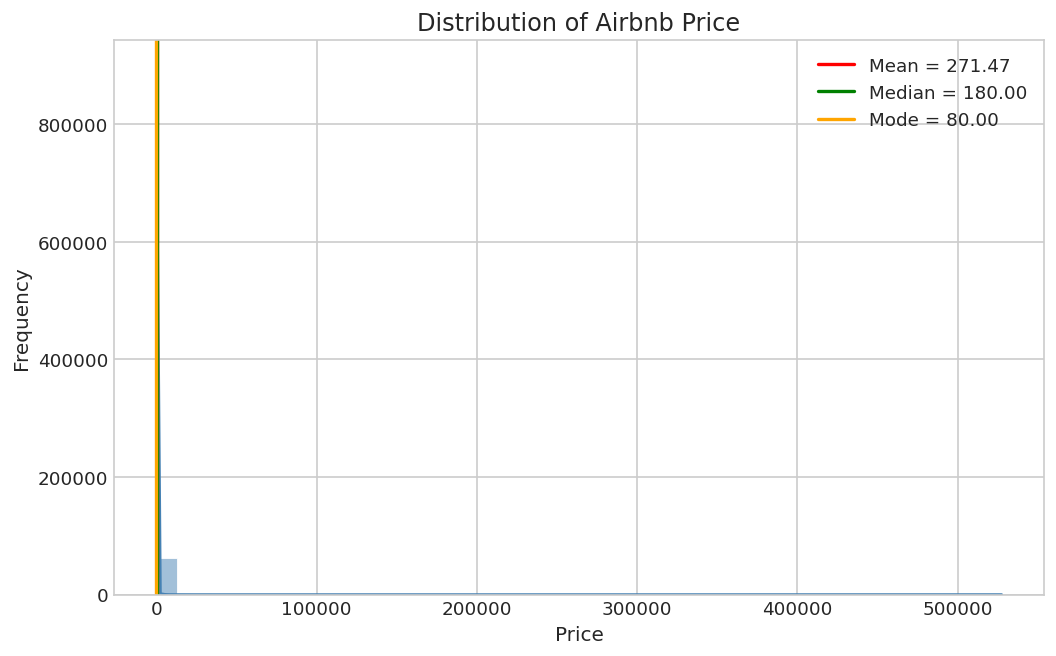

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

price = df["price"].dropna()

mean = price.mean()
median = price.median()
mode = price.mode()[0]

plt.figure(figsize=(10,6))

sns.histplot(price,
             bins=40,
             kde=True,
             color="steelblue")

plt.axvline(mean,
            color="red",
            linewidth=2,
            label=f"Mean = {mean:.2f}")

plt.axvline(median,
            color="green",
            linewidth=2,
            label=f"Median = {median:.2f}")

plt.axvline(mode,
            color="orange",
            linewidth=2,
            label=f"Mode = {mode:.2f}")

plt.title("Distribution of Airbnb Price")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.legend()

plt.show()

##Boxplot Analysis

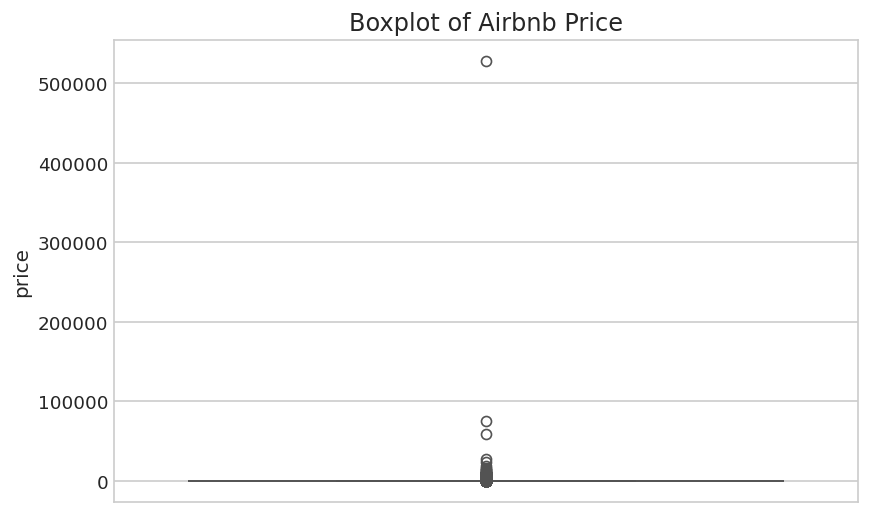

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["price"])

plt.title("Boxplot of Airbnb Price")

plt.show()

##Variance

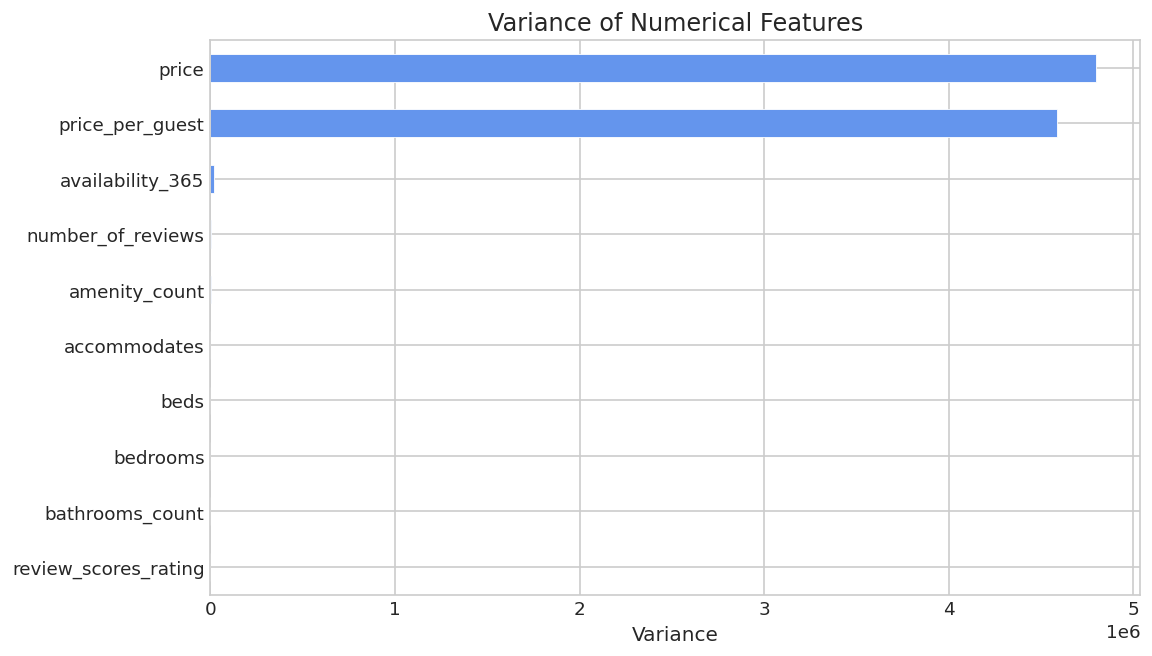

In [ ]:
variance = df[num_cols].var().sort_values()

plt.figure(figsize=(10,6))

variance.plot(kind="barh",
              color="cornflowerblue")

plt.title("Variance of Numerical Features")

plt.xlabel("Variance")

plt.show()

##Standard Deviation

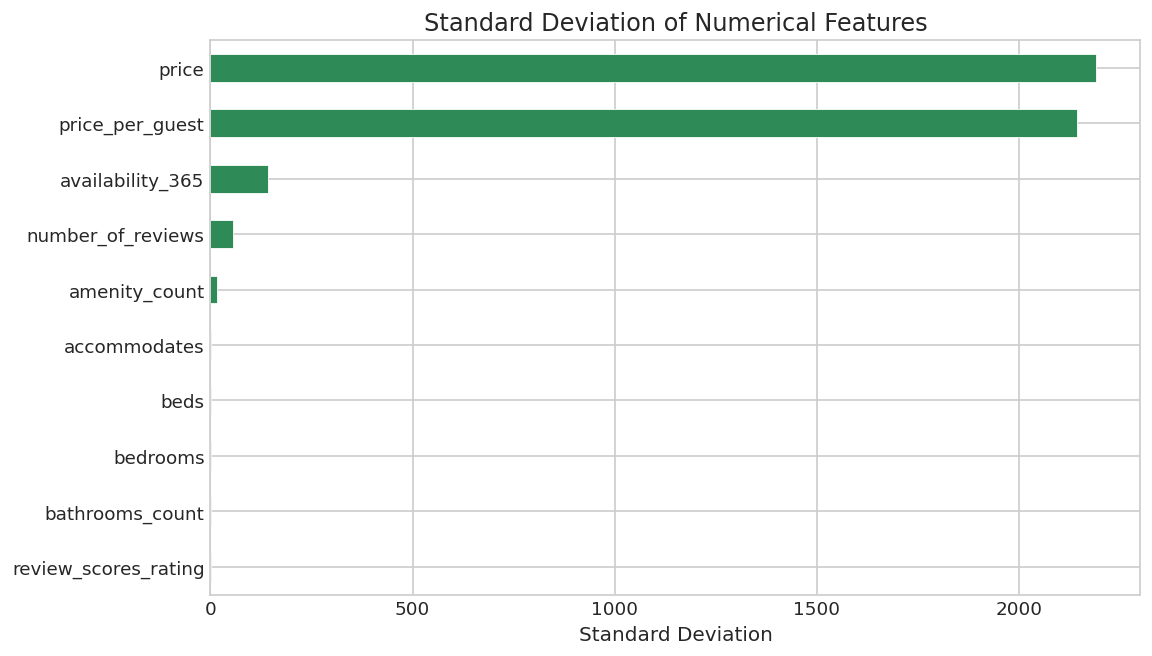

In [ ]:
std = df[num_cols].std().sort_values()

plt.figure(figsize=(10,6))

std.plot(kind="barh",
         color="seagreen")

plt.title("Standard Deviation of Numerical Features")

plt.xlabel("Standard Deviation")

plt.show()

##Deviation from Mean

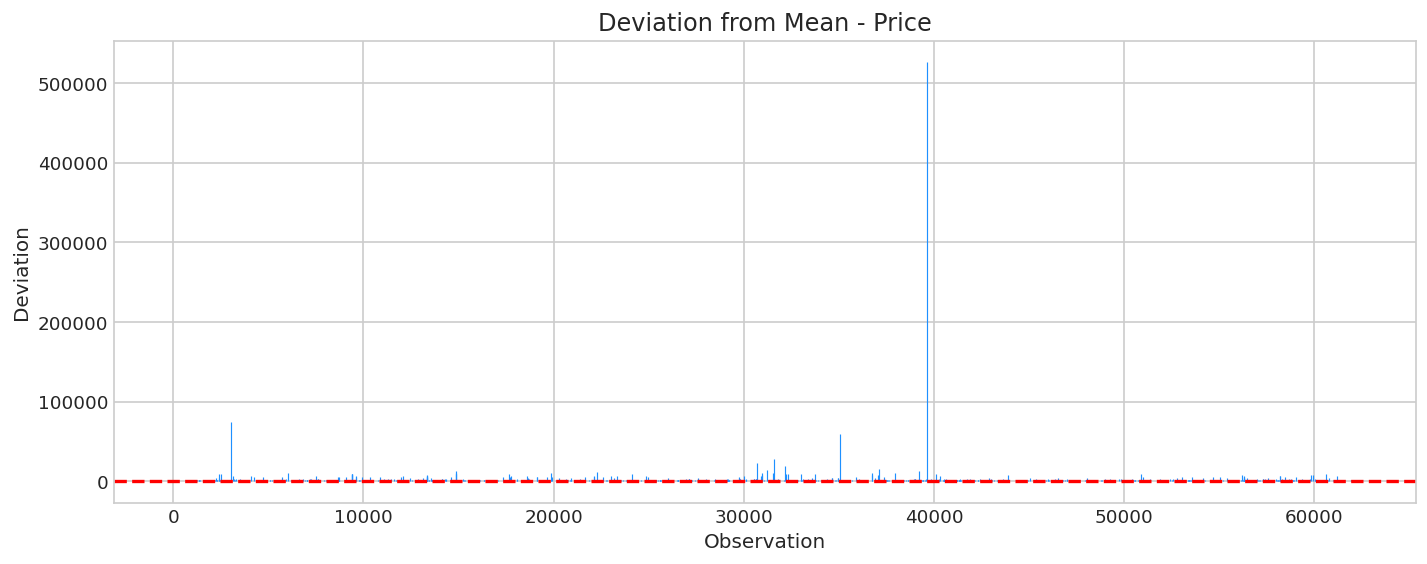

In [ ]:
price = df["price"].dropna()

deviation = price - price.mean()

plt.figure(figsize=(14,5))

plt.vlines(
    x=range(len(deviation)),
    ymin=0,
    ymax=deviation,
    color="dodgerblue",
    linewidth=0.7
)

plt.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Deviation from Mean - Price")

plt.xlabel("Observation")

plt.ylabel("Deviation")

plt.show()

##Standard Deviation Range

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


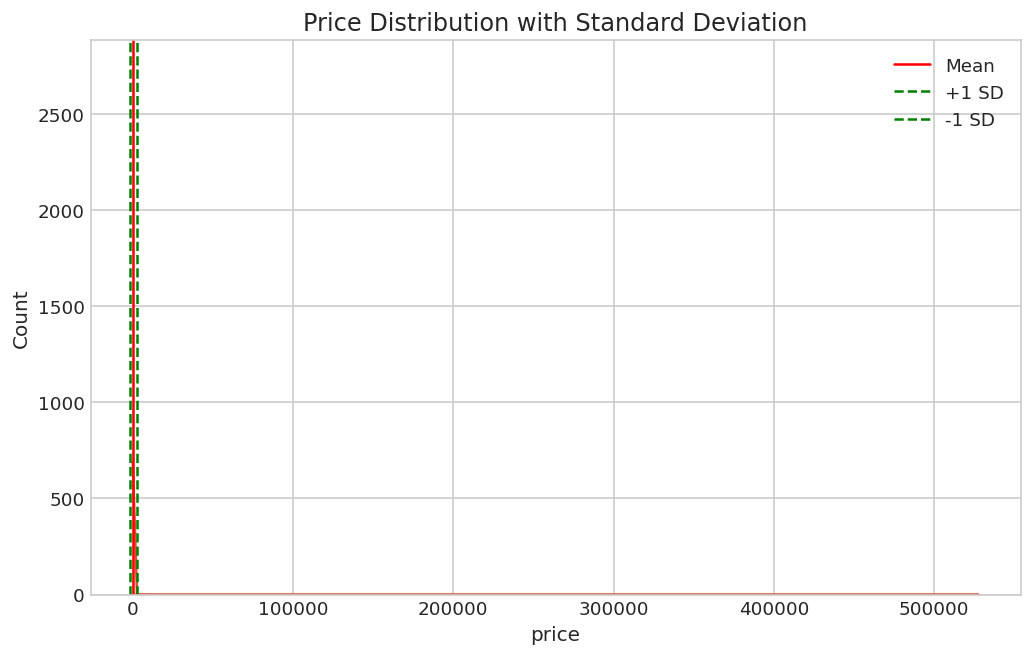

In [ ]:
mean = price.mean()
std = price.std()

plt.figure(figsize=(10,6))

sns.histplot(price,
             kde=True)

plt.axvline(mean,
            color="red",
            label="Mean")

plt.axvline(mean+std,
            color="green",
            linestyle="--",
            label="+1 SD")

plt.axvline(mean-std,
            color="green",
            linestyle="--",
            label="-1 SD")

plt.legend()

plt.title("Price Distribution with Standard Deviation")

plt.show()

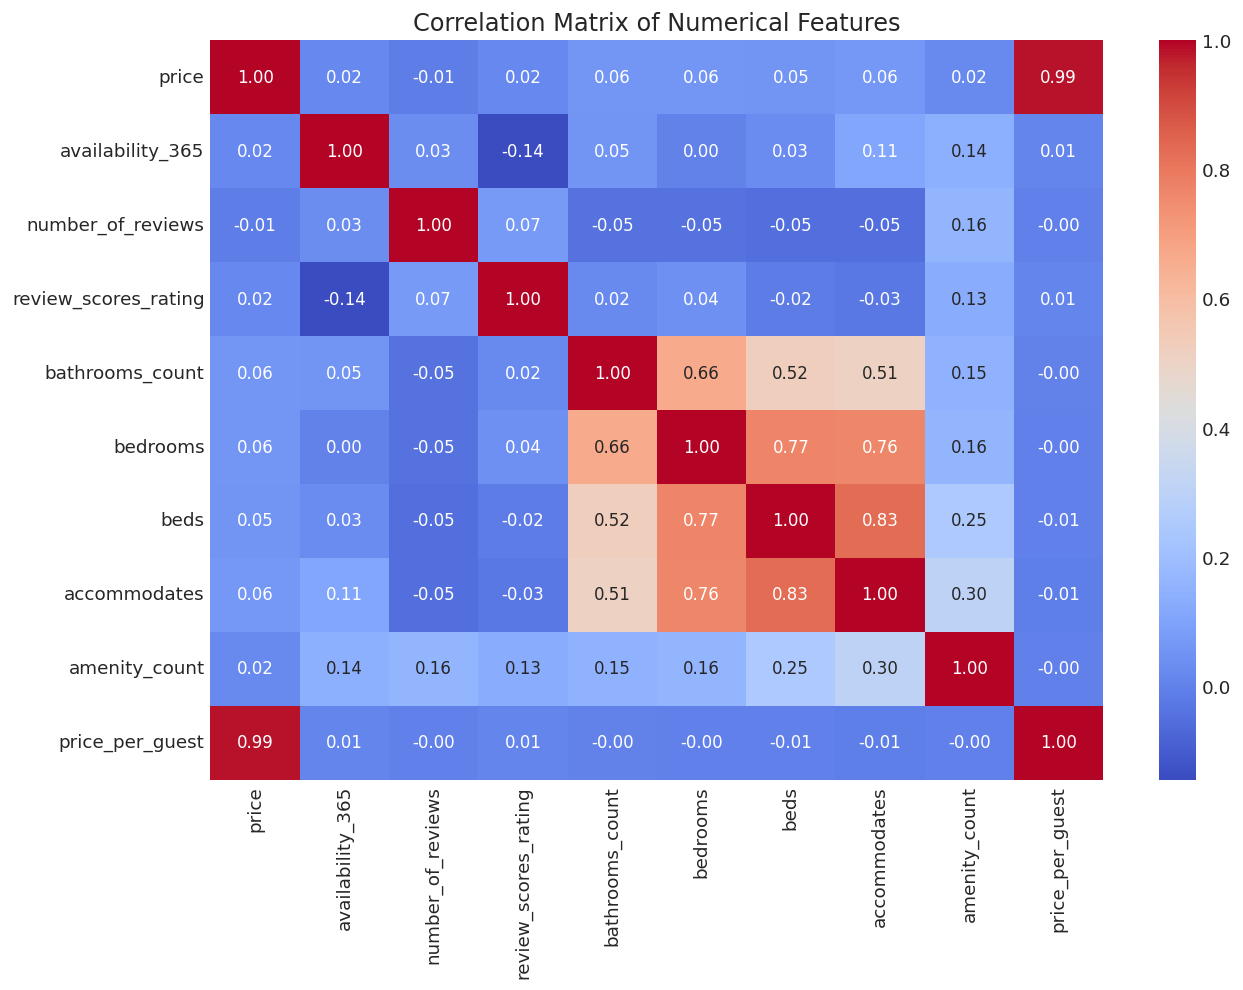

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

#Interpretation

###The distribution of Airbnb listing prices is positively skewed, with the mean exceeding the median. This indicates that while most listings are moderately priced, a relatively small number of luxury properties substantially increase the average listing price. Consequently, the median is a more representative measure of central tendency for this dataset.

#Business Data Visualization

##Price Distribution Across Room Types

###KPI Dashboard

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2,
    cols=3,
    specs=[
        [{"type":"indicator"},{"type":"indicator"},{"type":"indicator"}],
        [{"type":"indicator"},{"type":"indicator"},{"type":"indicator"}]
    ]
)

# Total Listings
fig.add_trace(go.Indicator(
    mode="number",
    value=df.shape[0],
    title={"text":"<b>Total Listings</b>"},
    number={"font":{"size":42}}
),1,1)

# Average Price
fig.add_trace(go.Indicator(
    mode="number",
    value=df["price"].mean(),
    number={"prefix":"£","font":{"size":42}},
    title={"text":"<b>Average Price</b>"}
),1,2)

# Average Rating (Gauge)
fig.add_trace(go.Indicator(
    mode="gauge+number",
    value=df["review_scores_rating"].mean(),
    title={"text":"<b>Average Rating</b>"},
    gauge={
        "axis":{"range":[0,5]},
        "bar":{"color":"#6C5CE7"},
        "steps":[
            {"range":[0,3],"color":"#FFD6D6"},
            {"range":[3,4],"color":"#FFE699"},
            {"range":[4,5],"color":"#D5F5E3"}
        ]
    }
),1,3)

# Total Reviews
fig.add_trace(go.Indicator(
    mode="number",
    value=df["number_of_reviews"].sum(),
    title={"text":"<b>Total Reviews</b>"},
    number={"font":{"size":42}}
),2,1)

# Average Availability
fig.add_trace(go.Indicator(
    mode="number",
    value=df["availability_365"].mean(),
    title={"text":"<b>Average Availability</b>"},
    number={"font":{"size":42}}
),2,2)

# Superhost %
fig.add_trace(go.Indicator(
    mode="gauge+number",
    value=(df["host_is_superhost"]=="t").mean()*100,
    number={"suffix":"%"},
    title={"text":"<b>Superhost %</b>"},
    gauge={
        "axis":{"range":[0,100]},
        "bar":{"color":"#00C2A8"},
        "steps":[
            {"range":[0,40],"color":"#FADBD8"},
            {"range":[40,70],"color":"#FCF3CF"},
            {"range":[70,100],"color":"#D4EFDF"}
        ]
    }
),2,3)

fig.update_layout(
    height=650,
    paper_bgcolor="#FFF8E7",
    font=dict(family="Arial",size=14),
    title={
        "text":"Airbnb London Executive KPI Dashboard",
        "x":0.5
    }
)

fig.show()

Interpretation:

The dashboard summarizes the key performance indicators of London's Airbnb market. It reveals the overall market size, pricing trends, guest satisfaction levels, listing availability, review activity, and host quality. These KPIs provide a high-level understanding of market performance and serve as a foundation for the detailed analyses presented in the subsequent visualizations.

##Treemap (Market Composition)

In [ ]:
property_price = (
    df.groupby("property_type")["price"]
      .mean()
      .reset_index()
)

property_price.columns = ["Property Type", "Average Price"]

fig = px.treemap(
    property_price,
    path=["Property Type"],
    values="Average Price",
    color="Average Price",
    color_continuous_scale="RdBu",
    title="Average Airbnb Price by Property Type"
)

fig.update_layout(title_x=0.5)

fig.show()

Interpretation

The treemap illustrates the composition of Airbnb property types in London. Entire rental units occupy the largest share of the market, followed by private rooms and entire homes. This indicates that London’s Airbnb market is primarily driven by whole-property rentals, reflecting strong demand from travelers seeking private accommodations.

##Interactive Plotly Map

In [ ]:
import plotly.express as px

# Sample data for better performance
sample = df[df["price"] < 500].sample(
    n=5000,
    random_state=42
)

fig = px.scatter_mapbox(
    sample,
    lat="latitude",
    lon="longitude",
    color="price",
    size="accommodates",
    hover_name="neighbourhood_cleansed",
    hover_data={
        "price": ":.2f",
        "room_type": True,
        "property_type": True,
        "review_scores_rating": ":.2f"
    },
    color_continuous_scale="Turbo",      # Better than RdYlGn_r
    zoom=9,
    height=700,
    title="Geographical Distribution of London Airbnb Listings by Price",
    mapbox_style="open-street-map"
)

fig.update_layout(
    paper_bgcolor="#FFF4CC",     # Warm cream background
    plot_bgcolor="#FFF4CC",
    title_x=0.5,
    margin=dict(l=10, r=10, t=60, b=10),
    font=dict(size=14)
)

fig.update_traces(
    marker=dict(
        opacity=0.75,
        sizemin=4
    )
)

fig.show()

Interpretation

The interactive map reveals the spatial distribution of Airbnb listings across London. Higher-priced listings tend to cluster in central and tourist-heavy areas, while lower-priced accommodations are more common in outer neighborhoods. This geographic concentration reflects differences in demand, accessibility, and local attractions.

##Donut Chart — Room Type Market Share

In [ ]:
room_share = (
    df["room_type"]
      .value_counts()
      .reset_index()
)

room_share.columns = ["Room Type", "Listings"]

fig = px.pie(
    room_share,
    names="Room Type",
    values="Listings",
    hole=0.55,
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="Market Share of Airbnb Room Types"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    title_x=0.5,
    legend_title="Room Type"
)

fig.show()

Interpretation

Entire homes/apartments represent the largest share of Airbnb listings, highlighting a strong preference for private accommodations. Private rooms form a substantial portion of the market, while shared rooms and hotel rooms account for only a small fraction of listings.

##Horizontal Bar Chart (Top 15 Boroughs by Average Price)

In [ ]:
import plotly.express as px

borough_price = (
    df.groupby("neighbourhood_cleansed")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
      .reset_index()
)

borough_price.columns = ["Borough", "Average Price"]

fig = px.bar(
    borough_price,
    x="Average Price",
    y="Borough",
    orientation="h",
    color="Average Price",
    color_continuous_scale="Plasma",
    text_auto=".2f",
    title="Top 15 London Boroughs by Average Airbnb Price"
)

fig.update_layout(
    paper_bgcolor="#F5F7FA",
    plot_bgcolor="#F5F7FA",
    title_x=0.5,
    height=650,
    xaxis_title="Average Price (£)",
    yaxis_title="London Borough",
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()

Interpretation

The chart highlights substantial differences in average Airbnb prices across London's boroughs. Central boroughs generally command higher average prices, reflecting stronger tourism demand, greater accessibility, and premium locations. In contrast, outer boroughs tend to offer more affordable accommodations, making them attractive to budget-conscious travelers.

##Bubble Chart(Price vs Review Score)

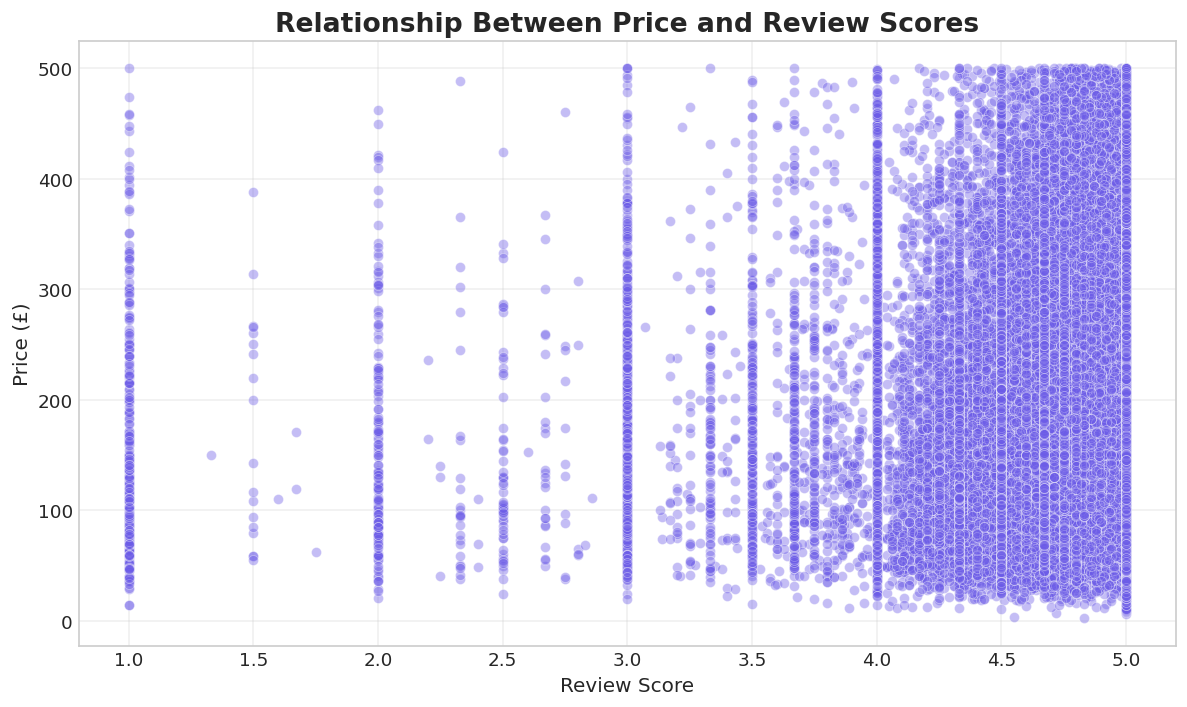

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df[
        (df["review_scores_rating"].notna()) &
        (df["price"] <= 500)
    ],
    x="review_scores_rating",
    y="price",
    alpha=0.4,
    color="#6C5CE7"
)

plt.title("Relationship Between Price and Review Scores", fontsize=16, fontweight="bold")
plt.xlabel("Review Score")
plt.ylabel("Price (£)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Interpretation – Bubble Chart

The bubble chart explores the relationship between listing price, guest ratings, and review volume across different room types. Most listings are concentrated in the high-rating range (4.5–5.0), indicating that Airbnb properties in London generally receive positive guest feedback. While higher-priced listings tend to maintain strong ratings, there is no clear evidence that increasing price alone guarantees better reviews. Larger bubbles, representing listings with a greater number of reviews, are primarily found in the mid-priced segment, suggesting that moderately priced accommodations attract more bookings and guest engagement than luxury listings. Additionally, the distribution of colors highlights that Entire Home/Apartments dominate the higher-price range, whereas Private Rooms are more common in the lower to mid-price segments.

##Plotly Funnel Chart(Superhost Status)

In [ ]:
fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[4, 5],
            gridcolor="lightgray",
            linecolor="gray"
        ),
        bgcolor="#00C2A8"   # Background inside radar chart
    ),

    paper_bgcolor="#F5F7FA",  # Background outside chart

    title="Guest Review Comparison: Superhosts vs Regular Hosts",
    title_x=0.5,

    font=dict(
        family="Arial",
        size=14,
        color="black"
    ),

    legend=dict(
        bgcolor="rgba(255,255,255,0.7)"
    )
)

Interpretation

 The funnel chart illustrates the distribution of Airbnb listings across different price categories. Most listings are concentrated in the Budget and Standard segments, while the number of listings decreases as prices increase. This indicates that London's Airbnb market is primarily driven by affordable and mid-range accommodations, with comparatively fewer premium and luxury listings.

#Key Insights
##London's Airbnb market is dominated by entire-home accommodations.

The Treemap and Donut Chart revealed that Entire Home/Apartments account for the largest share of listings. This suggests that the London Airbnb market primarily serves travelers seeking privacy and complete accommodations rather than shared spaces.

##Airbnb prices exhibit a highly right-skewed distribution.

The Price Distribution Histogram demonstrated that while most listings fall within the lower-to-mid price range, a relatively small number of luxury properties significantly increase the average price.

This indicates that the median price is a more reliable measure of central tendency than the mean when analyzing Airbnb pricing.

##Significant price variation exists across the London market.

The Variance, Standard Deviation, and Boxplot analyses showed substantial dispersion in listing prices, accompanied by numerous high-value outliers.

These outliers likely represent premium or luxury accommodations located in highly desirable areas and should be considered genuine market observations rather than data quality issues.

##Guest ratings remain consistently high regardless of price.

The Bubble Chart illustrated that the majority of listings receive ratings between 4.5 and 5.0, regardless of their price.

This suggests that charging higher prices does not necessarily guarantee higher guest satisfaction. Service quality and guest experience appear to be maintained across multiple price segments.

##Moderately priced listings attract greater guest engagement.

The bubble chart further indicated that listings with the largest number of reviews are generally concentrated within the mid-priced range rather than among the most expensive properties.

This suggests that competitively priced accommodations may experience higher booking frequency and greater guest interaction.

##The London Airbnb market is geographically concentrated.

The Interactive Plotly Map showed that listings are densely clustered in central London and popular tourist locations.

Higher-priced accommodations are predominantly located within central areas, whereas lower-priced listings become more common toward outer boroughs.

##Property type significantly influences pricing.

The Treemap highlighted clear differences in average prices across property types.

Larger and more exclusive accommodation types generally command higher prices, reflecting the premium guests place on privacy, space, and amenities.

##The market exhibits a diverse pricing hierarchy.

The Sunburst Chart demonstrated that pricing varies considerably across boroughs, room types, and property categories.

Certain boroughs contain a wider mix of accommodation options and price segments, indicating stronger market diversity and broader customer demand.

##Correlation analysis indicates limited linear relationships.

The Correlation Matrix showed that most numerical variables have weak-to-moderate correlations.

This suggests that Airbnb pricing is influenced by a combination of multiple factors rather than a single dominant variable, emphasizing the complexity of the market.

##Feature engineering provided deeper analytical value.

By creating additional variables such as Amenity Count, Bathrooms Count, and Price Category, the analysis extended beyond the raw dataset.

These engineered features enabled richer visualizations and more meaningful business interpretations that would not have been possible using the original variables alone.

#Conclusion

This project successfully conducted a comprehensive exploratory data analysis of Airbnb listings in London by integrating data cleaning, feature engineering, statistical analysis, and advanced interactive visualizations.



The analysis revealed that London's Airbnb market is predominantly composed of entire-home accommodations, with pricing displaying considerable variability and a strongly right-skewed distribution. Although premium listings command substantially higher prices, guest ratings remain consistently high across all price segments, indicating that guest satisfaction depends on factors beyond price alone.



Geographical analysis demonstrated a clear concentration of listings within central London, where demand and pricing are generally higher. At the same time, the market exhibits significant diversity across boroughs, property types, and accommodation categories, highlighting the complexity of London's short-term rental ecosystem.



The project also demonstrated the importance of rigorous data preparation and feature engineering in producing reliable and insightful analyses. By combining descriptive statistics with advanced interactive visualizations—including KPI dashboards, treemaps, interactive maps, donut charts, bubble charts, and sunburst diagrams—the analysis provided a holistic understanding of the London Airbnb marketplace.



Overall, this project showcases the complete data analysis workflow, from raw data preprocessing to actionable business insights, while demonstrating proficiency in Python, Pandas, NumPy, Matplotlib, Seaborn, and Plotly. It highlights the ability to transform complex datasets into clear, data-driven narratives that support informed decision-making for hosts, travelers, and business stakeholders.